In [1]:
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn

     |████████████████████████████████| 4.5 MB 5.0 MB/s eta 0:00:01


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier


/home/ip/.local/lib/python3.8/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


In [3]:
np.random.seed(42)

n = 10000

data = pd.DataFrame({
    "amount": np.random.uniform(10, 100000, n),
    "transaction_hour": np.random.randint(0, 24, n),
    "customer_age": np.random.randint(18, 70, n),
    "account_age_days": np.random.randint(1, 3000, n),
    "previous_transactions": np.random.randint(0, 100, n),
    "failed_attempts": np.random.randint(0, 6, n),
    "device_changed": np.random.randint(0, 2, n),
    "international": np.random.randint(0, 2, n)
})

# Fraud probability
fraud_score = (
    (data["amount"] > 70000).astype(int) * 0.25 +
    (data["failed_attempts"] >= 3).astype(int) * 0.25 +
    (data["device_changed"] == 1).astype(int) * 0.15 +
    (data["international"] == 1).astype(int) * 0.15 +
    ((data["transaction_hour"] < 5) | 
     (data["transaction_hour"] > 23)).astype(int) * 0.20
)

# Add random noise
fraud_score += np.random.normal(0, 0.10, n)

# Fraud label
data["is_fraud"] = (fraud_score > 0.45).astype(int)

data.head()


,amount,transaction_hour,customer_age,account_age_days,previous_transactions,failed_attempts,device_changed,international,is_fraud
0,37460.266484,22,33,1384,48,2,0,1,0
1,95071.923498,3,59,503,14,1,1,1,1
2,73202.074242,17,42,173,17,1,1,0,0
3,59869.861835,4,34,887,37,1,0,1,0
4,15610.303858,15,56,1418,88,1,0,0,0


In [4]:
print(data.shape)
print(data.isnull().sum())
print(data["is_fraud"].value_counts())


(10000, 9)
amount                   0
transaction_hour         0
customer_age             0
account_age_days         0
previous_transactions    0
failed_attempts          0
device_changed           0
international            0
is_fraud                 0
dtype: int64
is_fraud
0    6135
1    3865
Name: count, dtype: int64


In [5]:
X = data.drop("is_fraud", axis=1)
y = data["is_fraud"]


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (8000, 8)
Testing data: (2000, 8)


In [7]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [8]:
y_pred = model.predict(X_test)

print("Predictions completed!")


Predictions completed!


In [9]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)


Accuracy : 0.863
Precision: 0.8394557823129252
Recall   : 0.7981888745148771
F1 Score : 0.8183023872679045


In [10]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.90      0.89      1227
           1       0.84      0.80      0.82       773

    accuracy                           0.86      2000
   macro avg       0.86      0.85      0.85      2000
weighted avg       0.86      0.86      0.86      2000



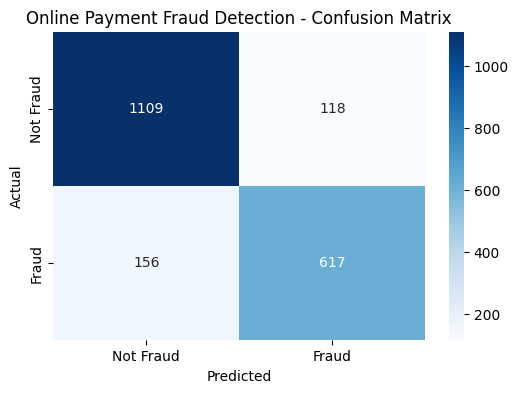

In [11]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Fraud", "Fraud"],
    yticklabels=["Not Fraud", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Online Payment Fraud Detection - Confusion Matrix")

plt.show()


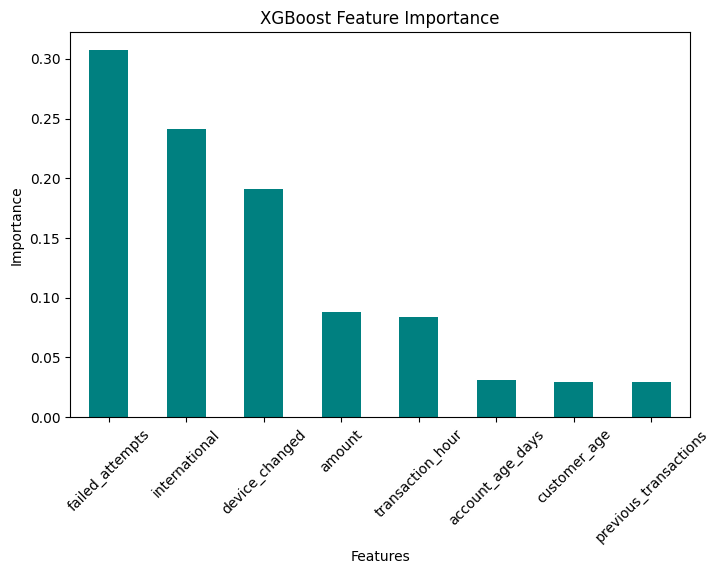

In [12]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))

importance.plot(kind="bar", color="teal")

plt.title("XGBoost Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.xticks(rotation=45)
plt.show()


In [13]:
new_transaction = pd.DataFrame({
    "amount": [85000],
    "transaction_hour": [2],
    "customer_age": [25],
    "account_age_days": [30],
    "previous_transactions": [5],
    "failed_attempts": [4],
    "device_changed": [1],
    "international": [1]
})

prediction = model.predict(new_transaction)[0]
probability = model.predict_proba(new_transaction)[0][1]

if prediction == 1:
    print("🚨 FRAUD TRANSACTION")
else:
    print("✅ LEGITIMATE TRANSACTION")

print("Fraud Probability:", round(probability * 100, 2), "%")


🚨 FRAUD TRANSACTION
Fraud Probability: 99.71 %
